# Мини-проект 3: De-novo genome assembly

```text
Гибридная сборка генома de-novo

- Короткие риды: точно, но медленно
- Длинные риды: быстро, но не точно

Зачастую используют гибридные сборки - риды Illumina картируются на скаффолды от Nanopore при сборке для ускорения операций или наоборот,
на сборку из Nanopore картируются риды Illumina для устранения неточностей

Повторы в геномах бактерий приводят к тому, что на одиночных ридах никогда не соберется 1 контиг из-за непонимания последовательности повторов в
геноме. Решение дает использование парных ридов

Собственно, проект:

- 2011 год, кишечная палочка стала причиной смерти нескольких людей. Был найден патогенный штамм E.Coli, который по идее не должен был вызывать такие
  симптомы и смерть. В геноме было найдено несколько серьезных отличий.

Задачи:

- Собрать геном патоганного штамма (методом короткой сборки и методом гибридной сборки)
- Найти референс и выровнять с помщью инструмента Mauve (программа конченная)
- Аннотирование с помощью prokka
- Подтвердить, что это связано с энтеротоксинами
- Проверить на устойчивость к антибиотикам
- Написать отчет
```

# Подготовка окружения и данных

In [ ]:
conda activate biolab

mkdir -p TASK3 && cd TASK3

mkdir -p RawData

wget https://d28rh4a8wq0iu5.cloudfront.net/bioinfo/SRR292678sub_S1_L001_R1_001.fastq.gz && \
wget https://d28rh4a8wq0iu5.cloudfront.net/bioinfo/SRR292678sub_S1_L001_R2_001.fastq.gz

mv SRR292678sub_S1_L001_R1_001.fastq.gz ./RawData && mv SRR292678sub_S1_L001_R2_001.fastq.gz ./RawData

cd RawData && gunzip SRR292678sub_S1_L001_R1_001.fastq.gz && gunzip SRR292678sub_S1_L001_R2_001.fastq.gz && cd ..

# Первичный анализ ридов и подготовка к сборке

In [ ]:
# Отчет FastQC

mkdir -p FASTQCrep/Forward && mkdir -p FASTQCrep/Reverse

fastqc ./RawData/SRR292678sub_S1_L001_R1_001.fastq -o ./FASTQCrep/Forward && fastqc ./RawData/SRR292678sub_S1_L001_R2_001.fastq -o ./FASTQCrep/Reverse

# Качество офигенное, можно не триммить

# Анализ длины генома через глубину покрытия

conda install -c bioconda jellyfish

which jellyfish # /home/suunar/miniforge3/envs/biolab/bin/jellyfish

# Если не указать канал, фиг вам, а не консольная утилита

# Получение гистограммы Jellyfish

mkdir -p Jellyfish && cd Jellyfish

jellyfish count -m 31 -s 5000000 -t 4 -o Kmer31.jf ../RawData/SRR292678sub_S1_L001_R1_001.fastq ../RawData/SRR292678sub_S1_L001_R2_001.fastq

jellyfish histo -t 4 -f -o histo31.histo Kmer31.jf

rm Kmer31.jf # Слишком много весит

# Гистограмма для k-меры 31

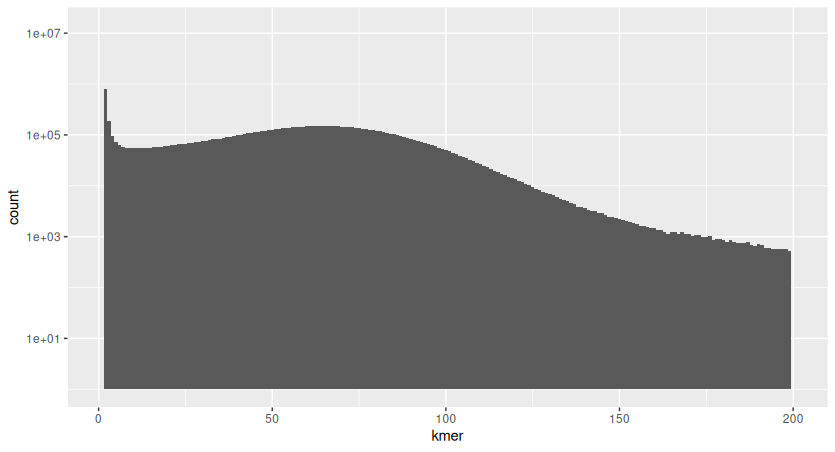

```text

Код:

setwd("~/R/projects")

resHist <- as.data.frame(read.csv('./histo.histo', sep=' ', col.names = c("kmer", "freq")))

resHist <- resHist[resHist$freq > 0, ]

library(ggplot2)

ggplot(resHist, aes(x = kmer, weight = freq)) + 
  geom_histogram(binwidth = 1) + 
  scale_x_continuous(limits = c(1, 200)) + scale_y_log10()

```

# Расчет размера генома

```text

Среднее покрытие составляет 64

Тогда размер генома:

(5499346 * 90 * (90 - 31 + 1))/(64 * 90) = 5155637

Просто ради интереса проверю на k-мерах 21 и 41

```

# Строим гистограммы для k-мер 21 и 41

In [ ]:
jellyfish count -m 21 -s 5000000 -t 4 -o Kmer21.jf ../RawData/SRR292678sub_S1_L001_R1_001.fastq ../RawData/SRR292678sub_S1_L001_R2_001.fastq

jellyfish histo -t 4 -f -o histo21.histo Kmer21.jf && rm Kmer21.jf

jellyfish count -m 41 -s 5000000 -t 4 -o Kmer41.jf ../RawData/SRR292678sub_S1_L001_R1_001.fastq ../RawData/SRR292678sub_S1_L001_R2_001.fastq

jellyfish histo -t 4 -f -o histo41.histo Kmer41.jf && rm Kmer41.jf

# Гистограмма для k-меры 21

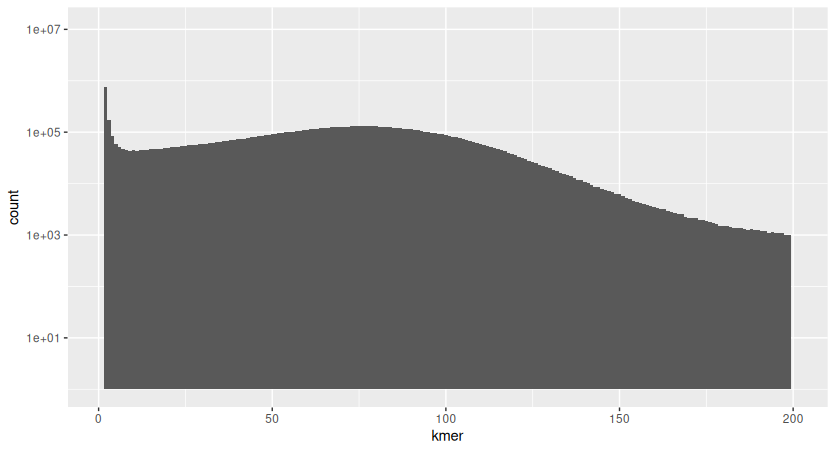

# Гистограмма для k-меры 41

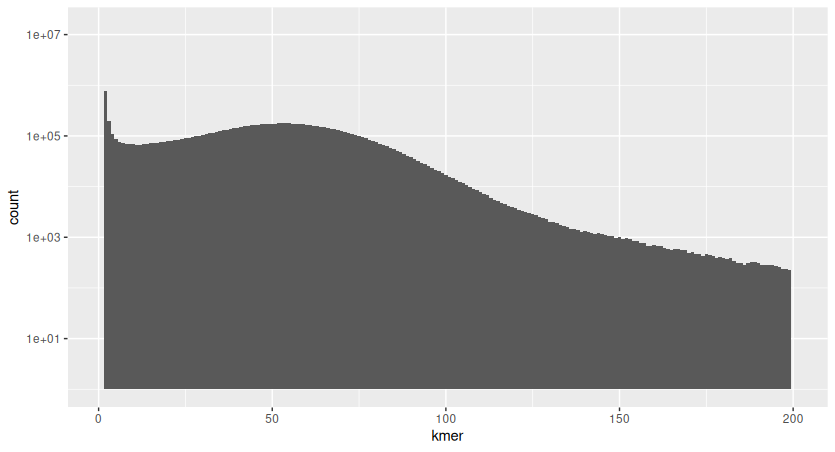

```text

Среднее покрытие составляет 75 для k-меры 21 и 52 для k-меры 41

Тогда размер генома:

По покрытию k-меры 21: (5499346 * 90 * (90 - 21 + 1))/(75 * 90) = 5132723

По покрытию k-меры 41: (5499346 * 90 * (90 - 41 + 1))/(52 * 90) = 5287833

Чет последнее выбивается

```

# Сборка генома через spades и оценка сборки через QUAST

In [ ]:
cd ..

conda activate SPAdes

spades.py -1 ./RawData/SRR292678sub_S1_L001_R1_001.fastq -2 ./RawData/SRR292678sub_S1_L001_R2_001.fastq -t 6 -o SPADESassembly

#Prjibelski, A., Antipov, D., Meleshko, D., Lapidus, A. and Korobeynikov, A., 2020. Using SPAdes de novo assembler. Current protocols in bioinformatics, 70(1), p.e102. doi.org/10.1002/cpbi.102

quast -o QUASTrep ./SPADESassembly/scaffolds.fasta

```text

Meh...

Assembly                    scaffolds
# contigs (>= 0 bp)         499      
# contigs (>= 1000 bp)      147      
# contigs (>= 5000 bp)      82       
# contigs (>= 10000 bp)     66       
# contigs (>= 25000 bp)     50       
# contigs (>= 50000 bp)     33       
Total length (>= 0 bp)      5316783  
Total length (>= 1000 bp)   5205502  
Total length (>= 5000 bp)   5045822  
Total length (>= 10000 bp)  4935654  
Total length (>= 25000 bp)  4685368  
Total length (>= 50000 bp)  4051686  
# contigs                   214      
Largest contig              300784   
Total length                5253645  
GC (%)                      50.51    
N50                         105346   
N90                         21421    
auN                         128949.0 
L50                         15       
L90                         52       
# N's per 100 kbp           32.23 

```

# Гибридная сборка

In [ ]:
# Скачиваем длинные риды

fasterq-dump --split-3 SRR1980037

# Собственно, сама сборка

spades.py -1 ./RawData/SRR292678sub_S1_L001_R1_001.fastq -2 ./RawData/SRR292678sub_S1_L001_R2_001.fastq --pacbio SRR1980037.fastq -o SPADESassemblyHYBR -t 6

quast -o QUASTrepHYBR ./SPADESassemblyHYBR/scaffolds.fasta

```text

Абсолютное величие для сборки de-novo

Assembly                    scaffolds
# contigs (>= 0 bp)         68       
# contigs (>= 1000 bp)      12       
# contigs (>= 5000 bp)      10       
# contigs (>= 10000 bp)     10       
# contigs (>= 25000 bp)     10       
# contigs (>= 50000 bp)     10       
Total length (>= 0 bp)      5438050  
Total length (>= 1000 bp)   5417075  
Total length (>= 5000 bp)   5414035  
Total length (>= 10000 bp)  5414035  
Total length (>= 25000 bp)  5414035  
Total length (>= 50000 bp)  5414035  
# contigs                   28       
Largest contig              2579824  
Total length                5428356  
GC (%)                      50.60    
N50                         968098   
N90                         202386   
auN                         1497443.1
L50                         2        
L90                         7        
# N's per 100 kbp           25.86

```

# Аннотирование сборок

In [ ]:
prokka --outdir ANNO --cpus 6 ./SPADESassembly/scaffolds.fasta

prokka --outdir ANNO_HYBR --cpus 6 ./SPADESassemblyHYBR/scaffolds.fasta #<-- Решил проаннотировать то, что собрано получше

# Seemann T (2014) Prokka: rapid prokaryotic genome annotation. Bioinformatics. 30(14):2068-9.